**KAGGLE API REQUIRED**

In [6]:
!pip install kaggle

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
#!/bin/bash
!kaggle datasets download omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown


In [9]:
from zipfile import ZipFile
dataset ='/content/face-mask-dataset.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('Dataset Extracted')

Dataset Extracted


Python Dependencies

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [11]:
masked_imgs = os.listdir('/content/data/with_mask')
unmasked_imgs = os.listdir('/content/data/without_mask')
print(masked_imgs[0:5])
print(masked_imgs[-5:])
print(unmasked_imgs[0:5])
print(unmasked_imgs[-5:])

['with_mask_94.jpg', 'with_mask_2145.jpg', 'with_mask_606.jpg', 'with_mask_2978.jpg', 'with_mask_3281.jpg']
['with_mask_109.jpg', 'with_mask_2228.jpg', 'with_mask_1514.jpg', 'with_mask_302.jpg', 'with_mask_1661.jpg']
['without_mask_1390.jpg', 'without_mask_740.jpg', 'without_mask_1538.jpg', 'without_mask_1775.jpg', 'without_mask_263.jpg']
['without_mask_1533.jpg', 'without_mask_663.jpg', 'without_mask_114.jpg', 'without_mask_2297.jpg', 'without_mask_282.jpg']


In [12]:
print('Ammount of images with masks:', len(masked_imgs))
print('Ammount of images without masks:', len(unmasked_imgs))

Ammount of images with masks: 3725
Ammount of images without masks: 3828


In [13]:
# Label creation for each image class
# Unmasked --> 0
# Masked --> 1

masked_lbl = [1]*3725
unmasked_lbl = [0]*3828

**Display Images**

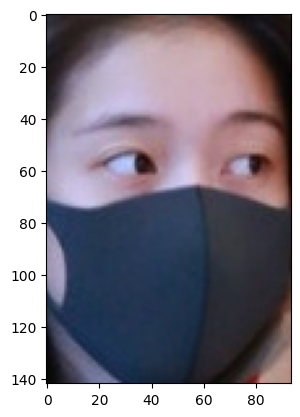

In [14]:
# Masked
img = mpimg.imread('/content/data/with_mask/with_mask_1060.jpg')
imgplot = plt.imshow(img)
plt.show()

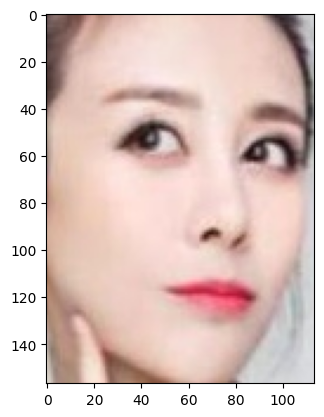

In [15]:
# Unmasked
img = mpimg.imread('/content/data/without_mask/without_mask_1158.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image processing**

1. Resize images (constant image size)
2. Convertion to numpy arrays

In [16]:
# Convertion to Numpy
masked_path = '/content/data/with_mask/'
unmasked_path = '/content/data/without_mask/'

data = []

for img_file in masked_imgs:
  image = Image.open(masked_path + img_file)
  image = image.resize((128, 128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

for img_file in unmasked_imgs:
  image = Image.open(unmasked_path + img_file)
  image = image.resize((128, 128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
len(data)

7553

array([[[105,  87,  75],
        [100,  82,  70],
        [ 94,  77,  66],
        ...,
        [ 79,  60,  44],
        [ 81,  62,  45],
        [ 93,  72,  55]],

       [[102,  84,  72],
        [116,  98,  86],
        [105,  87,  77],
        ...,
        [ 71,  52,  37],
        [ 74,  55,  38],
        [ 90,  69,  52]],

       [[ 88,  70,  58],
        [109,  91,  79],
        [101,  84,  74],
        ...,
        [ 89,  70,  55],
        [ 81,  62,  45],
        [ 71,  49,  32]],

       ...,

       [[153, 111,  99],
        [142, 100,  88],
        [139,  96,  84],
        ...,
        [183, 162, 134],
        [183, 162, 135],
        [180, 161, 133]],

       [[152, 109,  99],
        [138,  97,  86],
        [132,  88,  78],
        ...,
        [184, 163, 134],
        [183, 163, 132],
        [181, 162, 131]],

       [[152, 109, 100],
        [136,  93,  85],
        [130,  86,  77],
        ...,
        [181, 162, 132],
        [182, 163, 131],
        [182, 162, 129]]], dtype=uint8)
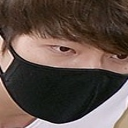

In [18]:
data[0]

In [19]:
print(data[0].shape)

(128, 128, 3)


In [20]:
# Convert Image list and label list to numpy

X = np.array(data)
Y = np.array(masked_lbl+unmasked_lbl)

In [21]:
print(X.shape) # 7553 arrays of 128x128 pixels and 3 layers (RGB)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


Training/Testing Data Split

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [24]:
# Data Scaling for better model performance
X_train_scaled = X_train/255
X_test_scaled = X_test/255

array([[[190, 190, 190],
        [189, 189, 189],
        [185, 185, 185],
        ...,
        [119, 119, 119],
        [121, 121, 121],
        [123, 123, 123]],

       [[170, 170, 170],
        [178, 178, 178],
        [191, 191, 191],
        ...,
        [117, 117, 117],
        [121, 121, 121],
        [126, 126, 126]],

       [[216, 216, 216],
        [220, 220, 220],
        [225, 225, 225],
        ...,
        [114, 114, 114],
        [121, 121, 121],
        [126, 126, 126]],

       ...,

       [[247, 248, 247],
        [141, 130, 124],
        [ 69,  50,  43],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[220, 215, 215],
        [104,  87,  81],
        [ 76,  57,  49],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[158, 146, 144],
        [ 91,  73,  63],
        [ 90,  72,  61],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
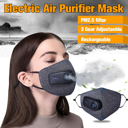

In [25]:
X_train[0]

In [26]:
X_train_scaled[0]

array([[[0.74509804, 0.74509804, 0.74509804],
        [0.74117647, 0.74117647, 0.74117647],
        [0.7254902 , 0.7254902 , 0.7254902 ],
        ...,
        [0.46666667, 0.46666667, 0.46666667],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.48235294, 0.48235294, 0.48235294]],

       [[0.66666667, 0.66666667, 0.66666667],
        [0.69803922, 0.69803922, 0.69803922],
        [0.74901961, 0.74901961, 0.74901961],
        ...,
        [0.45882353, 0.45882353, 0.45882353],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.49411765, 0.49411765, 0.49411765]],

       [[0.84705882, 0.84705882, 0.84705882],
        [0.8627451 , 0.8627451 , 0.8627451 ],
        [0.88235294, 0.88235294, 0.88235294],
        ...,
        [0.44705882, 0.44705882, 0.44705882],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.49411765, 0.49411765, 0.49411765]],

       ...,

       [[0.96862745, 0.97254902, 0.96862745],
        [0.55294118, 0.50980392, 0.48627451],
        [0.27058824, 0

**Convolutional Neural Network**

In [27]:
import tensorflow as tf
from tensorflow import keras

In [28]:
num_of_classes = 2
model = keras.Sequential ()

model.add(keras.layers.Conv2D(32,
                              kernel_size=(3,3),
                              activation='relu',
                              input_shape=(128, 128, 3)))

model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,
                              kernel_size=(3,3),
                              activation='relu'))

model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))

model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))

model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(2, activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Compile Neural Network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [30]:
# Training CNN
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=8)

Epoch 1/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.6870 - loss: 0.7170 - val_accuracy: 0.8430 - val_loss: 0.3160
Epoch 2/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8717 - loss: 0.3170 - val_accuracy: 0.8975 - val_loss: 0.2225
Epoch 3/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8939 - loss: 0.2588 - val_accuracy: 0.9223 - val_loss: 0.1821
Epoch 4/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9178 - loss: 0.1957 - val_accuracy: 0.9355 - val_loss: 0.1649
Epoch 5/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9216 - loss: 0.1973 - val_accuracy: 0.9306 - val_loss: 0.1527
Epoch 6/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9330 - loss: 0.1614 - val_accuracy: 0.9174 - val_loss: 0.1757
Epoch 7/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9362 - loss: 0.1637 - val_accuracy: 0.9372 - val_loss: 0.1442
Epoch 8/8
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9556 - loss: 0.1128 - val_accuracy: 

Model Evaluation

In [31]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9176 - loss: 0.2461
Test Accuracy = 0.9185969829559326


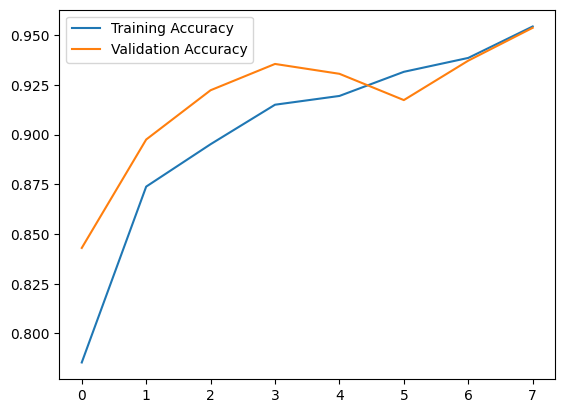

In [32]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()
plt.show()

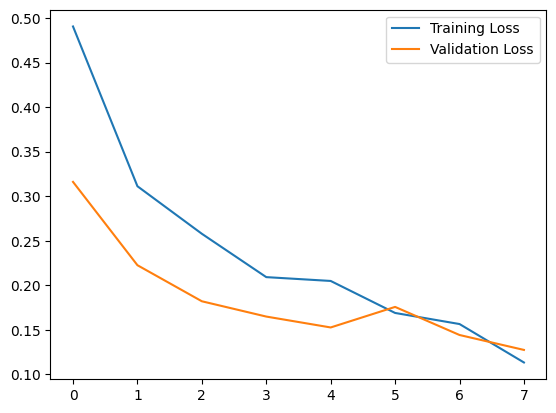

In [33]:
# Plot Loss
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

**Prediction System**

Path of the image to be predicted: /content/data/with_mask/with_mask_185.jpg


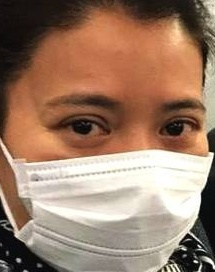

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.3764072  0.63004494]]
1
There is a person wearing a mask


In [39]:
input_img_path = input('Path of the image to be predicted: ')
input_img = cv2.imread(input_img_path)

cv2_imshow(input_img)

input_img_resize = cv2.resize(input_img, (128,128))

input_img_scaled = input_img_resize/255

input_img_reshape = np.reshape(input_img_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_img_reshape)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print('There is a person wearing a mask')
else:
  print('The person in the image is not wearing a mask')